# FlashAIR Demo Notebook
## 快速测试 FlashAIRa 和 FlashAIRx

本 Notebook 演示两个 IR 光谱预测系统的使用:
- **FlashAIRa**: 基于分子碎片化匹配的快速 IR 预测
- **FlashAIRx**: 基于物理先验 (XTB) + 残差校正 (GPR) 的高精度 IR 预测

### 使用前准备
1. 确保 `data/FlashAIR-QM9d.db` 数据库文件存在
2. 确保 `flashair/models/` 目录下有训练好的模型文件
3. 已安装所有依赖: rdkit, numpy, scipy, tensorflow, gpflow, matplotlib

In [1]:
# ==================== 环境检查 ====================

import sys
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

# 获取当前目录
notebook_dir = Path.cwd()
flashair_dir = notebook_dir.parent / 'flashair'
data_dir = notebook_dir.parent / 'data'

print("=" * 60)
print("FlashAIR Demo 环境检查")
print("=" * 60)

# 检查flashair目录
if flashair_dir.exists():
    sys.path.insert(0, str(flashair_dir))
    print(f"✅ FlashAIR目录: {flashair_dir}")
else:
    print(f"❌ 未找到FlashAIR目录: {flashair_dir}")

# 检查data目录
db_path = data_dir / 'FlashAIR-QM9d.db'
if db_path.exists():
    print(f"✅ 数据库: {db_path}")
else:
    print(f"❌ 数据库不存在: {db_path}")

# 检查models目录
models_dir = flashair_dir / 'models'
if models_dir.exists():
    print(f"✅ 模型目录: {models_dir}")
    model_files = list(models_dir.glob('*.pkl'))
    print(f"   包含模型: {[f.name for f in model_files]}")
else:
    print(f"❌ 模型目录不存在: {models_dir}")

FlashAIR Demo 环境检查
✅ FlashAIR目录: /mnt/d/chemdata/FlashAIR_git_new/flashair
✅ 数据库: /mnt/d/chemdata/FlashAIR_git_new/data/FlashAIR-QM9d.db
✅ 模型目录: /mnt/d/chemdata/FlashAIR_git_new/flashair/models
   包含模型: ['multi_fg_model_general.pkl', 'single_fg_model.pkl', 'xtb2dft_all_models.pkl', 'xtb2dft_models_dict.pkl']


In [2]:
# ==================== 导入依赖 ====================

import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("加载FlashAIR模块...")
print("=" * 60)

# FlashAIRa 预测模块
from FlashAIRa_Predictor import FlashAIRaPredictor, create_predictor

# FlashAIRx 预测模块
from FlashAIRx_prediction import FlashAIRxPredictor
from FlashAIRx_preprocess import preprocess, sqrt_norm

print("✅ FlashAIRa 和 FlashAIRx 模块加载完成")

# 设置绘图样式
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.dpi': 150
})

加载FlashAIR模块...


2026-07-06 02:35:50.607540: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-06 02:35:50.634607: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783276550.646226    3113 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783276550.649691    3113 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783276550.659332    3113 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

✅ FlashAIRa 和 FlashAIRx 模块加载完成


## 1. FlashAIRa 光谱预测
基于分子碎片化匹配的快速 IR 预测

In [7]:
# ==================== 初始化 FlashAIRa ====================

print("\n" + "=" * 60)
print("1. FlashAIRa 光谱预测")
print("=" * 60)

print("\n初始化 FlashAIRa 预测器 (测试模式，使用基础库)...")

predictor_a = FlashAIRaPredictor(
    db_path=str(db_path),
    test_mode=True,
)

info = predictor_a.get_library_info()
print(f"碎片库大小: {info['size']} 个分子")
print(f"官能团类型: {info['fg_types']}")


1. FlashAIRa 光谱预测

初始化 FlashAIRa 预测器 (测试模式，使用基础库)...
工作目录: /mnt/d/chemdata/FlashAIR_git_new/flashair/V0.8.8
碎片库大小: 20547 个分子
官能团类型: ['Alkyne', 'Nitrile', 'Alcohol', 'Aldehyde', 'Imine', 'Ether', 'Ketone', 'Amine', 'Ester', 'Aromatic', 'Amide', 'Carboxylic Acid', 'Alkene', 'Halide', 'Nitro']


In [8]:
# ==================== 自定义输入测试 ====================

# 在这里输入您想要测试的 SMILES
USER_SMILES = "CCO"  # 可修改为任意SMILES，例如: "CC(=O)O", "c1ccccc1", "CC(=O)OC"
USER_NAME = "乙醇"   # 可修改为对应的分子名称

print(f"\n测试分子: {USER_NAME} ({USER_SMILES})")
print("-" * 40)

result_a = predictor_a.predict_from_smiles(USER_SMILES)

if result_a['success']:
    print(f"✅ 预测成功")
    print(f"   匹配级别: {result_a['match_level']}")
    print(f"   匹配分子: {result_a['matched_smiles']}")
    print(f"   相似度: {result_a['match_similarity']:.4f}")
    print(f"   片段数: {len(result_a['fragments'])}")
    print(f"   光谱点数: {len(result_a['predicted_ir'])}")
else:
    print(f"❌ 预测失败: {result_a['error']}")


测试分子: 乙醇 (CCO)
----------------------------------------
✅ 预测成功
   匹配级别: L1
   匹配分子: CCO
   相似度: 1.0000
   片段数: 1
   光谱点数: 825


In [9]:
# ==================== FlashAIRa 批量测试 ====================

test_smiles_a = [
    ("CCO", "乙醇"),
    ("CC(=O)O", "乙酸"),
    ("c1ccccc1", "苯"),
    ("CC(=O)OC", "乙酸甲酯"),
    ("C1=CC=CC=C1C(=O)O", "苯甲酸"),
]

print("\n批量测试 FlashAIRa:")
print("-" * 40)

results_a = []

for smiles, name in test_smiles_a:
    result = predictor_a.predict_from_smiles(smiles)
    if result['success']:
        results_a.append((name, result))
        print(f"  {name:8s} | {result['match_level']:4s} | 相似度: {result['match_similarity']:.4f}")
    else:
        print(f"  {name:8s} | ❌ 失败: {result['error']}")


批量测试 FlashAIRa:
----------------------------------------
  乙醇       | L1   | 相似度: 1.0000
  乙酸       | L3   | 相似度: 0.1905
  苯        | L1   | 相似度: 1.0000
  乙酸甲酯     | L1   | 相似度: 1.0000
  苯甲酸      | L4   | 相似度: 0.6000



绘制 FlashAIRa 预测光谱...


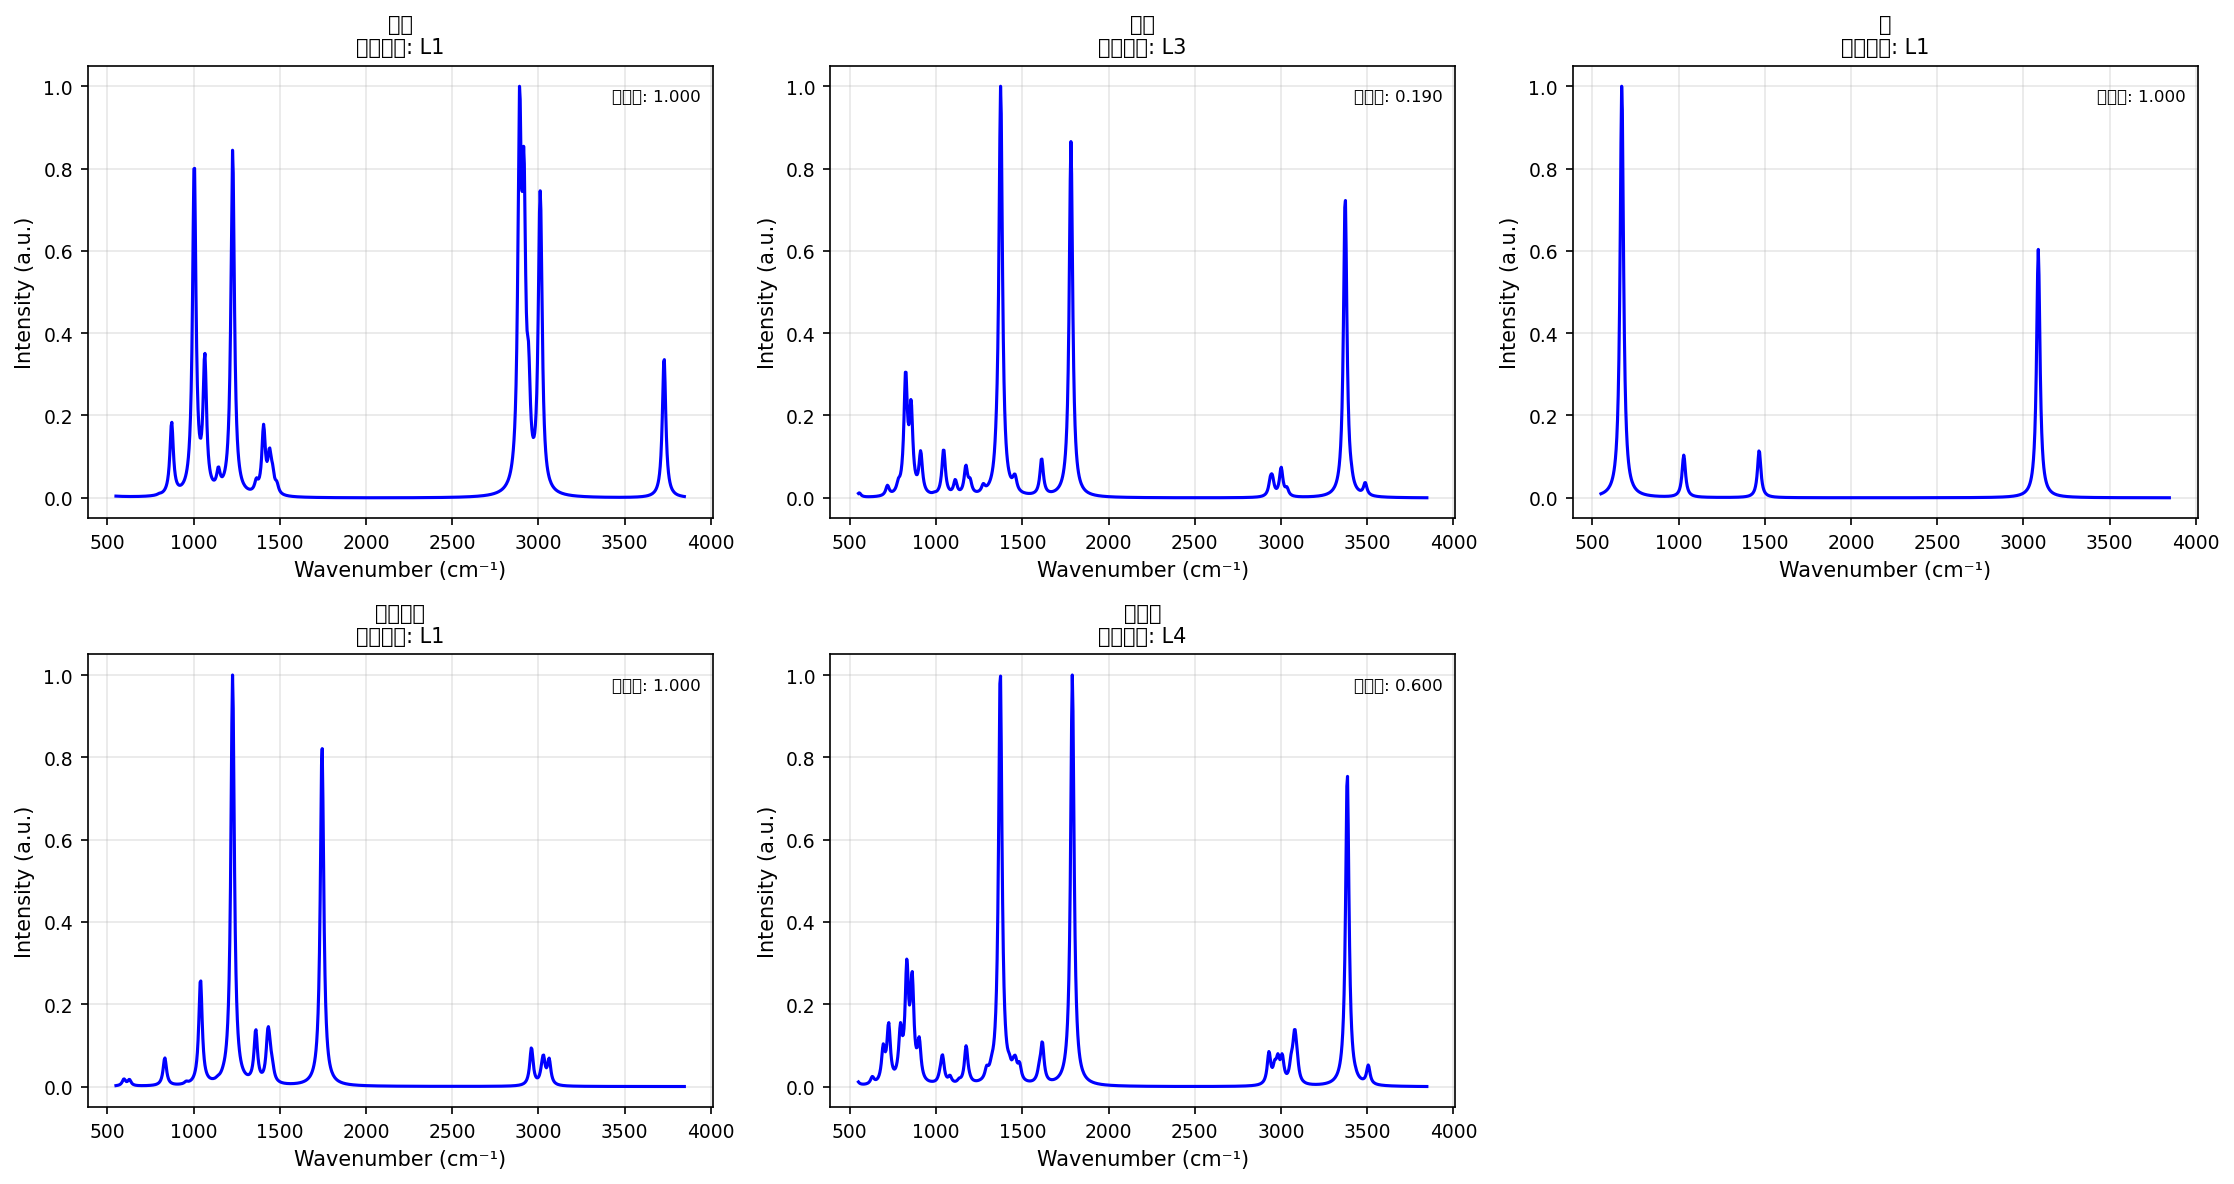

✅ FlashAIRa 预测完成! 结果已保存为 flashaira_results.png


In [6]:
# ==================== FlashAIRa 绘图 ====================

print("\n绘制 FlashAIRa 预测光谱...")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, (name, result) in enumerate(results_a[:6]):
    ax = axes[idx]
    wavenumber = result['wavenumber']
    pred_ir = result['predicted_ir']
    
    ax.plot(wavenumber, pred_ir, 'b-', linewidth=1.5)
    ax.set_title(f"{name}\n匹配级别: {result['match_level']}", fontsize=10)
    ax.set_xlabel("Wavenumber (cm⁻¹)")
    ax.set_ylabel("Intensity (a.u.)")
    ax.grid(True, alpha=0.3)
    ax.text(0.98, 0.95, f"相似度: {result['match_similarity']:.3f}", 
            transform=ax.transAxes, ha='right', va='top', fontsize=8)

# 隐藏多余的子图
for idx in range(len(results_a), 6):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig('flashaira_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ FlashAIRa 预测完成! 结果已保存为 flashaira_results.png")

## 2. FlashAIRx 光谱预测
基于物理先验 (XTB) + 残差校正 (GPR) 的高精度 IR 预测

In [3]:
# ==================== 初始化 FlashAIRx ====================

print("\n" + "=" * 60)
print("2. FlashAIRx 光谱预测")
print("=" * 60)

print("\n初始化 FlashAIRx 预测器...")

predictor_x = FlashAIRxPredictor(
    model_dir=models_dir,
    model_dict_path=models_dir / 'xtb2dft_all_models.pkl',
    gpr_exp_path=models_dir / 'dft2exp_model.pkl' if (models_dir / 'dft2exp_model.pkl').exists() else None
)

print(f"XTB→DFT 模型数: {len(predictor_x.model_dict)}")
print(f"DFT→EXP 模型: {'已加载' if predictor_x.gpr_model_exp else '未加载(仅DFT模式)'}")


2. FlashAIRx 光谱预测

初始化 FlashAIRx 预测器...
加载模型字典: xtb2dft_all_models.pkl


I0000 00:00:1783276570.060143    3113 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5529 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:01:00.0, compute capability: 8.9


  ✅ 已加载 374 个模型
  GPflow: 18, sklearn: 356
  键示例: [('Nitrile',), ('Alkyne',), ('Alkane',), ('Ester',), ('Alkene',)]
         ... 共 374 个键
XTB→DFT 模型数: 374
DFT→EXP 模型: 未加载(仅DFT模式)


In [4]:
# ==================== FlashAIRx 预测 ====================

# 测试分子
test_smiles_x = [
    "CCO",
    "CC(=O)O",
    "c1ccccc1",
    "CC(=O)OC",
    "C1=CC=CC=C1C(=O)O",
]

print("\n开始 FlashAIRx 预测 (需要运行XTB计算，可能需要几分钟)...")
print("-" * 40)

results_x = []

for smiles in test_smiles_x:
    print(f"\n  处理: {smiles}")
    
    # 步骤1: 预处理 (SMILES → XTB光谱)
    preprocess_result = preprocess(
        input_data=smiles,
        input_type="smiles",
        output_dir=notebook_dir / "temp" / "xtb_work",
        nproc=1
    )
    
    if not preprocess_result['success']:
        print(f"    ❌ 预处理失败: {preprocess_result['error']}")
        continue
    
    xtb_spectrum = preprocess_result['gpr_input']['X']
    functional_groups = preprocess_result['gpr_input']['functional_groups']
    
    print(f"    ✅ XTB光谱提取成功, 官能团: {functional_groups}")
    
    # 步骤2: GPR预测 (XTB → DFT)
    predict_result = predictor_x.predict_dft_only(
        xtb_spectrum=xtb_spectrum,
        functional_groups=functional_groups,
        exact_match_only=False
    )
    
    if predict_result['success']:
        print(f"    ✅ DFT预测成功, 匹配模型: {predict_result['matched_key']}")
        results_x.append({
            'smiles': smiles,
            'functional_groups': functional_groups,
            'xtb_spectrum': xtb_spectrum,
            'dft_spectrum': predict_result['dft_spectrum'],
            'matched_key': predict_result['matched_key'],
            'wavenumber': predict_result['wavenumber']
        })
    else:
        print(f"    ❌ DFT预测失败: {predict_result['error']}")


开始 FlashAIRx 预测 (需要运行XTB计算，可能需要几分钟)...
----------------------------------------

  处理: CCO
    ✅ XTB光谱提取成功, 官能团: ('Alcohol',)


I0000 00:00:1783276591.548996    3113 cuda_solvers.cc:175] Creating GpuSolver handles for stream 0x5bc4ddc813f0


    ✅ DFT预测成功, 匹配模型: ('Alcohol',)

  处理: CC(=O)O
    ✅ XTB光谱提取成功, 官能团: ('Carboxylic Acid',)
    ✅ DFT预测成功, 匹配模型: ('Carboxylic Acid',)

  处理: c1ccccc1
    ✅ XTB光谱提取成功, 官能团: ('Aromatic',)
    ✅ DFT预测成功, 匹配模型: ('Aromatic',)

  处理: CC(=O)OC
    ✅ XTB光谱提取成功, 官能团: ('Ester',)
    ✅ DFT预测成功, 匹配模型: ('Ester',)

  处理: C1=CC=CC=C1C(=O)O
    ✅ XTB光谱提取成功, 官能团: ('Aromatic', 'Carboxylic Acid')
    ✅ DFT预测成功, 匹配模型: ('Carboxylic Acid',)



绘制 FlashAIRx 预测光谱...


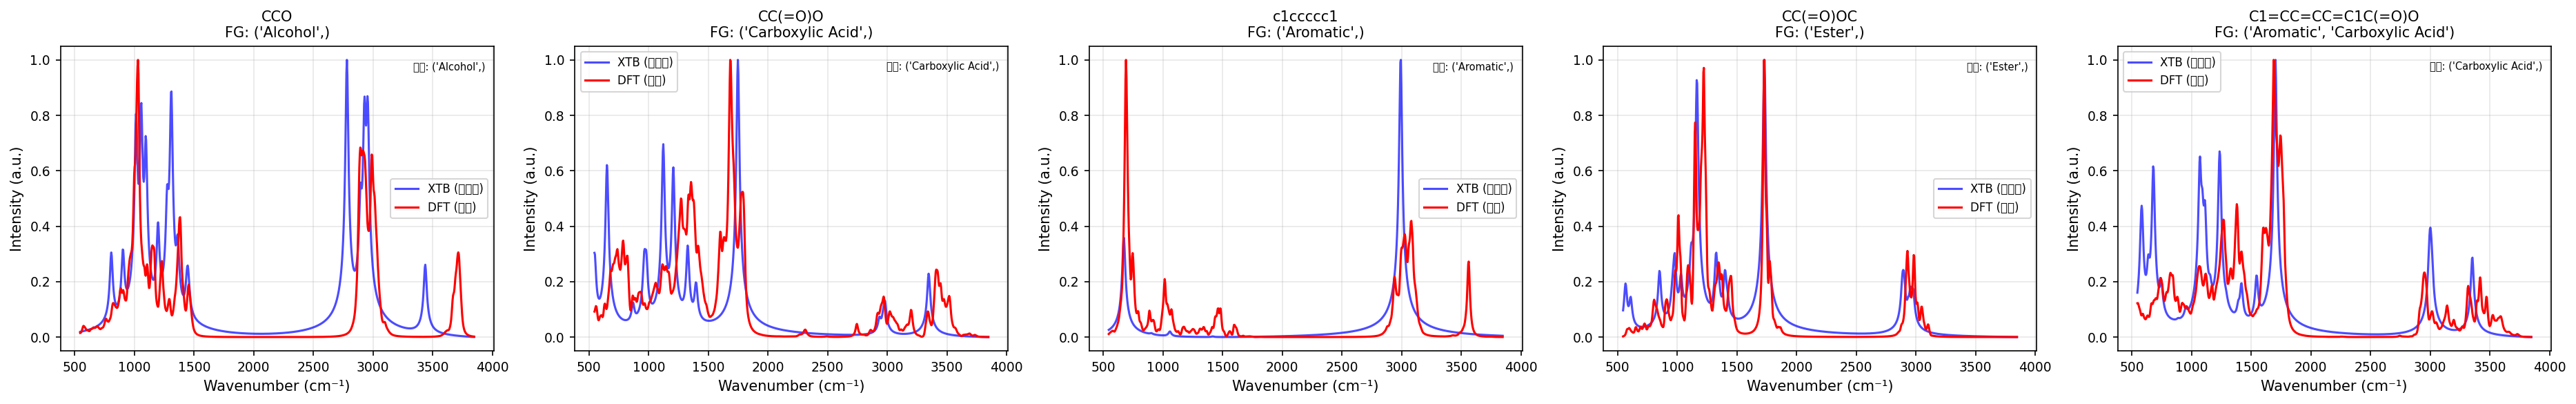

✅ FlashAIRx 预测完成! 结果已保存为 flashairx_results.png


In [5]:
# ==================== FlashAIRx 绘图 ====================

if results_x:
    print("\n绘制 FlashAIRx 预测光谱...")

    fig, axes = plt.subplots(1, len(results_x), figsize=(5 * len(results_x), 4))
    if len(results_x) == 1:
        axes = [axes]

    for idx, res in enumerate(results_x):
        ax = axes[idx]
        wavenumber = res['wavenumber']
        xtb = res['xtb_spectrum']
        dft = res['dft_spectrum']
        
        ax.plot(wavenumber, xtb, 'b-', linewidth=1.5, label='XTB (归一化)', alpha=0.7)
        ax.plot(wavenumber, dft, 'r-', linewidth=1.5, label='DFT (校正)')
        ax.set_title(f"{res['smiles']}\nFG: {res['functional_groups']}", fontsize=10)
        ax.set_xlabel("Wavenumber (cm⁻¹)")
        ax.set_ylabel("Intensity (a.u.)")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
        ax.text(0.98, 0.95, f"模型: {res['matched_key']}", 
                transform=ax.transAxes, ha='right', va='top', fontsize=7)

    plt.tight_layout()
    plt.savefig('flashairx_results.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("✅ FlashAIRx 预测完成! 结果已保存为 flashairx_results.png")
else:
    print("\n❌ 没有成功的 FlashAIRx 预测结果")

## 3. 自定义输入预测

In [10]:
# ==================== 自定义输入预测 ====================

# 在这里输入您想要测试的 SMILES
CUSTOM_SMILES = "CCO"  # 可修改为任意SMILES
CUSTOM_NAME = "乙醇"   # 可修改为对应的分子名称

print("=" * 60)
print(f"自定义预测: {CUSTOM_NAME} ({CUSTOM_SMILES})")
print("=" * 60)

# FlashAIRa 预测
print("\n[FlashAIRa]")
result_custom_a = predictor_a.predict_from_smiles(CUSTOM_SMILES)

if result_custom_a['success']:
    print(f"  匹配级别: {result_custom_a['match_level']}")
    print(f"  相似度: {result_custom_a['match_similarity']:.4f}")
else:
    print(f"  ❌ 失败: {result_custom_a['error']}")

# FlashAIRx 预测
print("\n[FlashAIRx]")

preprocess_result = preprocess(
    input_data=CUSTOM_SMILES,
    input_type="smiles",
    output_dir=notebook_dir / "temp" / "xtb_work",
    nproc=1
)

if preprocess_result['success']:
    xtb_spectrum = preprocess_result['gpr_input']['X']
    functional_groups = preprocess_result['gpr_input']['functional_groups']
    
    predict_result = predictor_x.predict_dft_only(
        xtb_spectrum=xtb_spectrum,
        functional_groups=functional_groups,
        exact_match_only=False
    )
    
    if predict_result['success']:
        print(f"  官能团: {functional_groups}")
        print(f"  匹配模型: {predict_result['matched_key']}")
        print(f"  DFT光谱点数: {len(predict_result['dft_spectrum'])}")
    else:
        print(f"  ❌ 预测失败: {predict_result['error']}")
else:
    print(f"  ❌ 预处理失败: {preprocess_result['error']}")

自定义预测: 乙醇 (CCO)

[FlashAIRa]
  匹配级别: L1
  相似度: 1.0000

[FlashAIRx]
  官能团: ('Alcohol',)
  匹配模型: ('Alcohol',)
  DFT光谱点数: 825


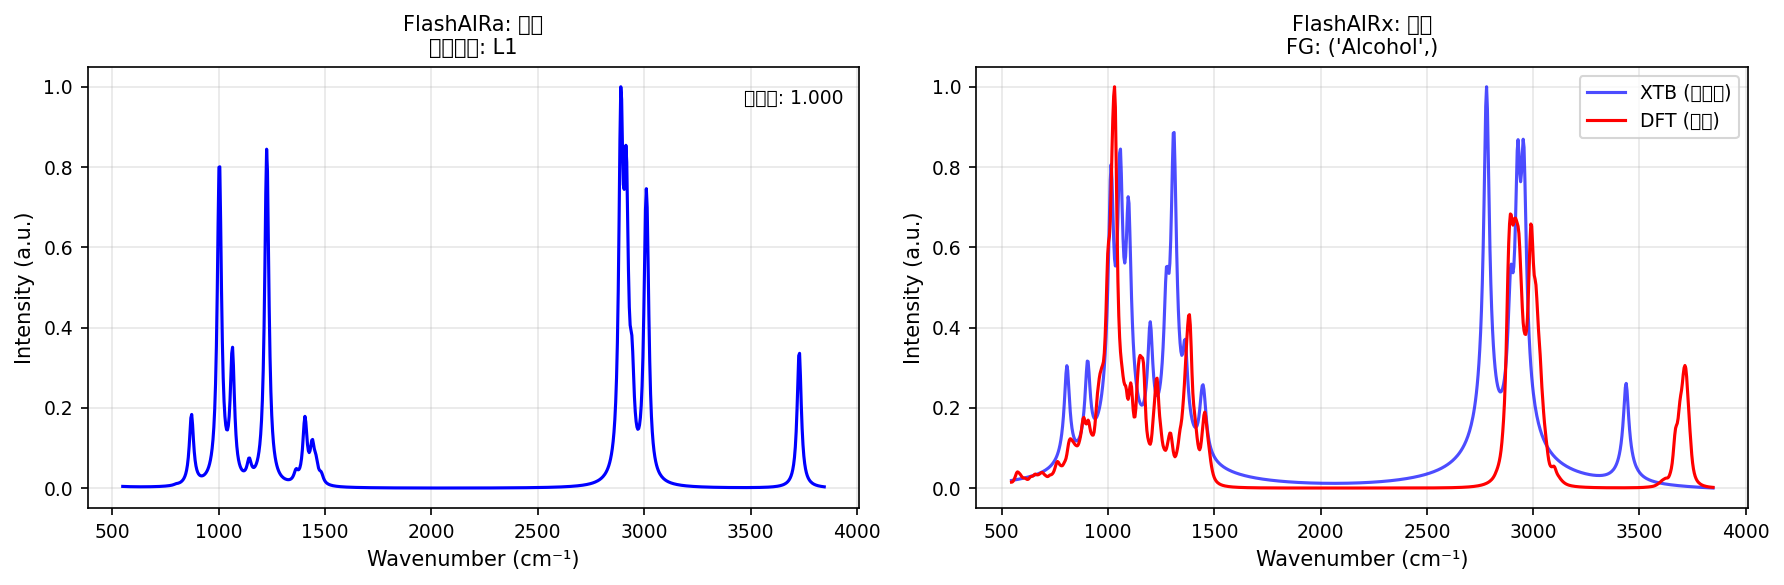

✅ 自定义预测完成! 结果已保存为 custom_prediction_results.png


In [11]:
# ==================== 自定义输入绘图 ====================

if result_custom_a['success'] and preprocess_result['success'] and predict_result['success']:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # FlashAIRa 结果
    ax = axes[0]
    wavenumber = result_custom_a['wavenumber']
    ax.plot(wavenumber, result_custom_a['predicted_ir'], 'b-', linewidth=1.5)
    ax.set_title(f"FlashAIRa: {CUSTOM_NAME}\n匹配级别: {result_custom_a['match_level']}", fontsize=10)
    ax.set_xlabel("Wavenumber (cm⁻¹)")
    ax.set_ylabel("Intensity (a.u.)")
    ax.grid(True, alpha=0.3)
    ax.text(0.98, 0.95, f"相似度: {result_custom_a['match_similarity']:.3f}", 
            transform=ax.transAxes, ha='right', va='top', fontsize=9)

    # FlashAIRx 结果
    ax = axes[1]
    wavenumber = predict_result['wavenumber']
    ax.plot(wavenumber, xtb_spectrum, 'b-', linewidth=1.5, label='XTB (归一化)', alpha=0.7)
    ax.plot(wavenumber, predict_result['dft_spectrum'], 'r-', linewidth=1.5, label='DFT (校正)')
    ax.set_title(f"FlashAIRx: {CUSTOM_NAME}\nFG: {functional_groups}", fontsize=10)
    ax.set_xlabel("Wavenumber (cm⁻¹)")
    ax.set_ylabel("Intensity (a.u.)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig('custom_prediction_results.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("✅ 自定义预测完成! 结果已保存为 custom_prediction_results.png")
else:
    print("\n❌ 无法绘制: 部分预测失败")

## 总结

### FlashAIRa 特点
- ✅ 快速预测 (无需XTB计算)
- ✅ 适合高通量筛选
- ⚠️ 精度依赖于匹配库

### FlashAIRx 特点
- ✅ 高精度校正 (GPR残差校正)
- ✅ 物理先验 (XTB计算)
- ⚠️ 需要XTB计算 (耗时)

### 使用建议
- 快速筛选: 使用 FlashAIRa
- 高精度分析: 使用 FlashAIRx
- 两者结合: 先用 FlashAIRa 快速筛选，再用 FlashAIRx 精修